## 2.7.3 Categorical Consistency Analysis across NorthStar Datasets

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# Upload ZIP to Colab
# ============================================

from google.colab import files

uploaded = files.upload()


Saving northstar_dataset.zip to northstar_dataset.zip


In [5]:
# ============================================
# Extract ZIP file
# ============================================

import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
# ============================================
# Check extracted folder
# ============================================

import os

os.listdir("northstar_dataset/northstar_dataset")

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [12]:
# ============================================
# Load Datasets
# ============================================

import pandas as pd

base_path = "northstar_dataset/northstar_dataset"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
deliveries = pd.read_csv(f"{base_path}/deliveries.csv")
drivers = pd.read_csv(f"{base_path}/drivers.csv")
vehicles = pd.read_csv(f"{base_path}/vehicles.csv")
hubs = pd.read_csv(f"{base_path}/hubs.csv")
incidents = pd.read_csv(f"{base_path}/incidents.csv")
complaints = pd.read_csv(f"{base_path}/complaints.csv")
app_events = pd.read_csv(f"{base_path}/app_events.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [18]:
# ============================================
# STORE DATASETS IN DICTIONARY
# ============================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

In [24]:
# ============================================
# IDENTIFY CATEGORICAL COLUMNS
# ============================================

print("CATEGORICAL VALUE ANALYSIS\n")

for name, df in datasets.items():
    print("\n============================")
    print(name.upper())
    print("============================")

    cat_cols = df.select_dtypes(include=['object']).columns
    print("Categorical Columns:", list(cat_cols))

CATEGORICAL VALUE ANALYSIS


CUSTOMERS
Categorical Columns: ['customer_id', 'home_zone', 'customer_type', 'signup_date', 'preferred_channel', 'account_status']

ORDERS
Categorical Columns: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'pickup_zone', 'dropoff_zone', 'priority_level', 'booking_channel']

DELIVERIES
Categorical Columns: ['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status']

DRIVERS
Categorical Columns: ['driver_id', 'base_zone', 'employment_type', 'shift_preference']

VEHICLES
Categorical Columns: ['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date', 'maintenance_status', 'telematics_version']

HUBS
Categorical Columns: ['hub_id', 'hub_name', 'zone', 'hub_type']

INCIDENTS
Categorical Columns: ['incident_id', 'delivery_id', 'incident_type', 'reported_at', 'severity', 'resolution_status']

COMPLAINTS
Categorical Columns: ['complaint_id', 'customer_id', 'order_id', 'compla

In [25]:
# ============================================
# INCONSISTENT CATEGORICAL VALUE ANALYSIS
# ============================================

inconsistency_report = []

for name, df in datasets.items():

    cat_cols = df.select_dtypes(include=['object']).columns

    for col in cat_cols:

        # remove nulls
        values = df[col].dropna()

        # basic inconsistency indicators

        unique_count = values.nunique()
        lowercase_unique = values.str.lower().nunique()
        stripped_unique = values.str.strip().nunique()

        inconsistency_score = unique_count - min(lowercase_unique, stripped_unique)

        inconsistency_report.append({
            "Dataset": name,
            "Column": col,
            "Unique Values": unique_count,
            "Lowercase Unique": lowercase_unique,
            "Stripped Unique": stripped_unique,
            "Inconsistency Score": inconsistency_score
        })

inconsistency_df = pd.DataFrame(inconsistency_report)

inconsistency_df

,Dataset,Column,Unique Values,Lowercase Unique,Stripped Unique,Inconsistency Score
0,customers,customer_id,650,650,650,0
1,customers,home_zone,16,8,16,8
2,customers,customer_type,3,3,3,0
3,customers,signup_date,650,650,650,0
4,customers,preferred_channel,4,4,4,0
5,customers,account_status,3,3,3,0
6,orders,order_id,1250,1250,1250,0
7,orders,customer_id,568,568,568,0
8,orders,service_type,5,5,5,0
9,orders,order_created_at,1248,1248,1248,0


In [26]:
# ============================================
# FILTER HIGH INCONSISTENCY COLUMNS
# ============================================

problematic_columns = inconsistency_df[
    inconsistency_df["Inconsistency Score"] > 0
]

problematic_columns

,Dataset,Column,Unique Values,Lowercase Unique,Stripped Unique,Inconsistency Score
1,customers,home_zone,16,8,16,8
10,orders,pickup_zone,16,8,16,8
11,orders,dropoff_zone,16,8,16,8
23,drivers,base_zone,16,8,16,8
28,vehicles,assigned_zone,16,8,16,8
57,app_events,zone_context,16,8,16,8


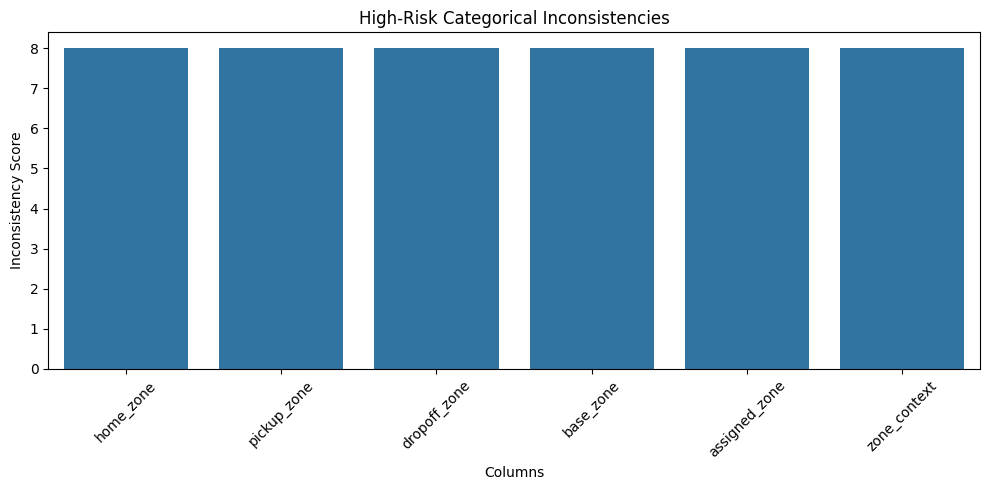

In [27]:
# ============================================
# SIMPLIFIED VISUALIZATION (TOP ISSUES ONLY)
# ============================================

top_issue = problematic_columns.copy()

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_issue,
    x="Column",
    y="Inconsistency Score"
)

plt.title("High-Risk Categorical Inconsistencies")
plt.xlabel("Columns")
plt.ylabel("Inconsistency Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation

The categorical consistency analysis across the NorthStar datasets identified inconsistencies in zone-related attributes, including home_zone, pickup_zone, dropoff_zone, base_zone, assigned_zone, and zone_context.

These inconsistencies are caused by variations in text formatting, including case differences (e.g., "north" vs "NORTH") and whitespace variations. As a result, the same logical category is represented in multiple forms, increasing the number of unique values artificially.

After normalization checks (lowercasing and trimming), the number of unique categories reduces significantly, confirming that the issue is due to inconsistent formatting rather than actual data variation.

This highlights the importance of standardising categorical values before performing SQL joins, aggregations, and analytical modelling in later chapters.